In [2]:
print("hello world")

hello world


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
train_df=pd.read_csv("E:/Uninversity/Semester 4/Intro to DS/archive (4)/train.csv")
test_df=pd.read_csv("E:/Uninversity/Semester 4/Intro to DS/archive (4)/test.csv")
train_df.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
train_df.tail()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
3955,ff8a2de4,Fall,13,0,Spring,60.0,Fall,16.362460,59.5,82.4,...,1.0,1.0,0.0,32.0,Winter,35.0,50.0,Fall,1.0,1.0
3956,ffa9794a,Winter,10,0,NaN,NaN,Spring,18.764678,53.5,76.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Winter,0.0,NaN
3957,ffcd4dbd,Fall,11,0,Spring,68.0,Winter,21.441500,60.0,109.8,...,1.0,0.0,1.0,31.0,Winter,56.0,77.0,Fall,0.0,1.0
3958,ffed1dd5,Spring,13,0,Spring,70.0,Winter,12.235895,70.7,87.0,...,1.0,1.0,1.0,19.0,Spring,33.0,47.0,Spring,1.0,0.0
3959,ffef538e,Spring,11,0,NaN,NaN,Winter,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,1.0,NaN


In [5]:
print(train_df.shape) 

(3960, 82)


In [6]:
train_df["SDS-Season"].value_counts()

SDS-Season
Spring    712
Winter    652
Summer    635
Fall      619
Name: count, dtype: int64

In [7]:
train_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Basic_Demos-Age,3960.0,10.433586,3.574648,5.0,8.00000,10.000000,13.000000,22.000000
Basic_Demos-Sex,3960.0,0.372727,0.483591,0.0,0.00000,0.000000,1.000000,1.000000
CGAS-CGAS_Score,2421.0,65.454771,22.341862,25.0,59.00000,65.000000,75.000000,999.000000
Physical-BMI,3022.0,19.331929,5.113934,0.0,15.86935,17.937682,21.571244,59.132048
Physical-Height,3027.0,55.946713,7.473764,33.0,50.00000,55.000000,62.000000,78.500000
...,...,...,...,...,...,...,...,...
PCIAT-PCIAT_Total,2736.0,27.896199,20.338853,0.0,12.00000,26.000000,41.000000,93.000000
SDS-SDS_Total_Raw,2609.0,41.088923,10.427433,17.0,33.00000,39.000000,46.000000,96.000000
SDS-SDS_Total_T,2606.0,57.763622,13.196091,38.0,47.00000,55.000000,64.000000,100.000000
PreInt_EduHx-computerinternet_hoursday,3301.0,1.060588,1.094875,0.0,0.00000,1.000000,2.000000,3.000000


In [8]:
pd.set_option('display.max_rows', None)   # Show all rows
pd.set_option('display.max_columns', None) 

In [9]:
train_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 82 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      3960 non-null   object 
 1   Basic_Demos-Enroll_Season               3960 non-null   object 
 2   Basic_Demos-Age                         3960 non-null   int64  
 3   Basic_Demos-Sex                         3960 non-null   int64  
 4   CGAS-Season                             2555 non-null   object 
 5   CGAS-CGAS_Score                         2421 non-null   float64
 6   Physical-Season                         3310 non-null   object 
 7   Physical-BMI                            3022 non-null   float64
 8   Physical-Height                         3027 non-null   float64
 9   Physical-Weight                         3076 non-null   float64
 10  Physical-Waist_Circumference            898 non-null    floa

In [10]:
threshold=0.5 * len(train_df)
train_data_coulmns=train_df.columns[train_df.isnull().sum()<threshold]
df=train_df[train_data_coulmns]
display_pdf=df.fillna(0)

In [11]:
display_pdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 69 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      3960 non-null   object 
 1   Basic_Demos-Enroll_Season               3960 non-null   object 
 2   Basic_Demos-Age                         3960 non-null   int64  
 3   Basic_Demos-Sex                         3960 non-null   int64  
 4   CGAS-Season                             3960 non-null   object 
 5   CGAS-CGAS_Score                         3960 non-null   float64
 6   Physical-Season                         3960 non-null   object 
 7   Physical-BMI                            3960 non-null   float64
 8   Physical-Height                         3960 non-null   float64
 9   Physical-Weight                         3960 non-null   float64
 10  Physical-Diastolic_BP                   3960 non-null   floa

In [12]:
targeted_coulmn="sii"
train_cleaned_df=display_pdf.dropna(subset=[targeted_coulmn])
train_cleaned_df.head()


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PCIAT-Season,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,0.0,0.0,0.0,Fall,0.0,0.0,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,Fall,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,Fall,5.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,0,0.0,0.0,Fall,3.0,2.0
1,000fd460,Summer,9,0,0,0.0,Fall,14.035590,48.0,46.0,75.0,70.0,122.0,Fall,3.0,0.0,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,Winter,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.21172,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,Fall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,65.0,94.0,117.0,Fall,20.0,1.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,0,0.0,0.00000,0.0000,0.000,0.00,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.0000,0.00000,0.0000,0.0000,0.0000,Fall,5.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,60.0,97.0,117.0,Summer,18.0,1.0,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,Summer,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.22033,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,Summer,4.0,2.0,4.0,0.0,5.0,1.0,0.0,3.0,2.0,2.0,3.0,0.0,3.0,0.0,0.0,3.0,4.0,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,0016bb22,Spring,18,1,Summer,0.0,0,0.000000,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.00000,0.0000,0.000,0.00,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.0000,0.00000,0.0000,0.0000,0.0000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0.0,0.0


In [13]:
train_cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 69 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      3960 non-null   object 
 1   Basic_Demos-Enroll_Season               3960 non-null   object 
 2   Basic_Demos-Age                         3960 non-null   int64  
 3   Basic_Demos-Sex                         3960 non-null   int64  
 4   CGAS-Season                             3960 non-null   object 
 5   CGAS-CGAS_Score                         3960 non-null   float64
 6   Physical-Season                         3960 non-null   object 
 7   Physical-BMI                            3960 non-null   float64
 8   Physical-Height                         3960 non-null   float64
 9   Physical-Weight                         3960 non-null   float64
 10  Physical-Diastolic_BP                   3960 non-null   floa

In [14]:
train_df.shape

(3960, 82)

In [15]:
train_df.isnull().sum().sum()

np.int64(131717)

In [16]:
(train_df.isnull().sum()/df.shape[0])*100

id                                         0.000000
Basic_Demos-Enroll_Season                  0.000000
Basic_Demos-Age                            0.000000
Basic_Demos-Sex                            0.000000
CGAS-Season                               35.479798
CGAS-CGAS_Score                           38.863636
Physical-Season                           16.414141
Physical-BMI                              23.686869
Physical-Height                           23.560606
Physical-Weight                           22.323232
Physical-Waist_Circumference              77.323232
Physical-Diastolic_BP                     25.404040
Physical-HeartRate                        25.075758
Physical-Systolic_BP                      25.404040
Fitness_Endurance-Season                  66.969697
Fitness_Endurance-Max_Stage               81.237374
Fitness_Endurance-Time_Mins               81.313131
Fitness_Endurance-Time_Sec                81.313131
FGC-Season                                15.505051
FGC-FGC_CU  

In [17]:
(train_df.isnull().sum().sum()/(df.shape[0]*df.shape[1]))*100

np.float64(48.205606792563316)

In [18]:
train_cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 69 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      3960 non-null   object 
 1   Basic_Demos-Enroll_Season               3960 non-null   object 
 2   Basic_Demos-Age                         3960 non-null   int64  
 3   Basic_Demos-Sex                         3960 non-null   int64  
 4   CGAS-Season                             3960 non-null   object 
 5   CGAS-CGAS_Score                         3960 non-null   float64
 6   Physical-Season                         3960 non-null   object 
 7   Physical-BMI                            3960 non-null   float64
 8   Physical-Height                         3960 non-null   float64
 9   Physical-Weight                         3960 non-null   float64
 10  Physical-Diastolic_BP                   3960 non-null   floa

In [19]:
(train_cleaned_df.isnull().sum().sum()/(df.shape[0]*df.shape[1]))*100

np.float64(0.0)

In [20]:
train_df.columns

Index(['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST'

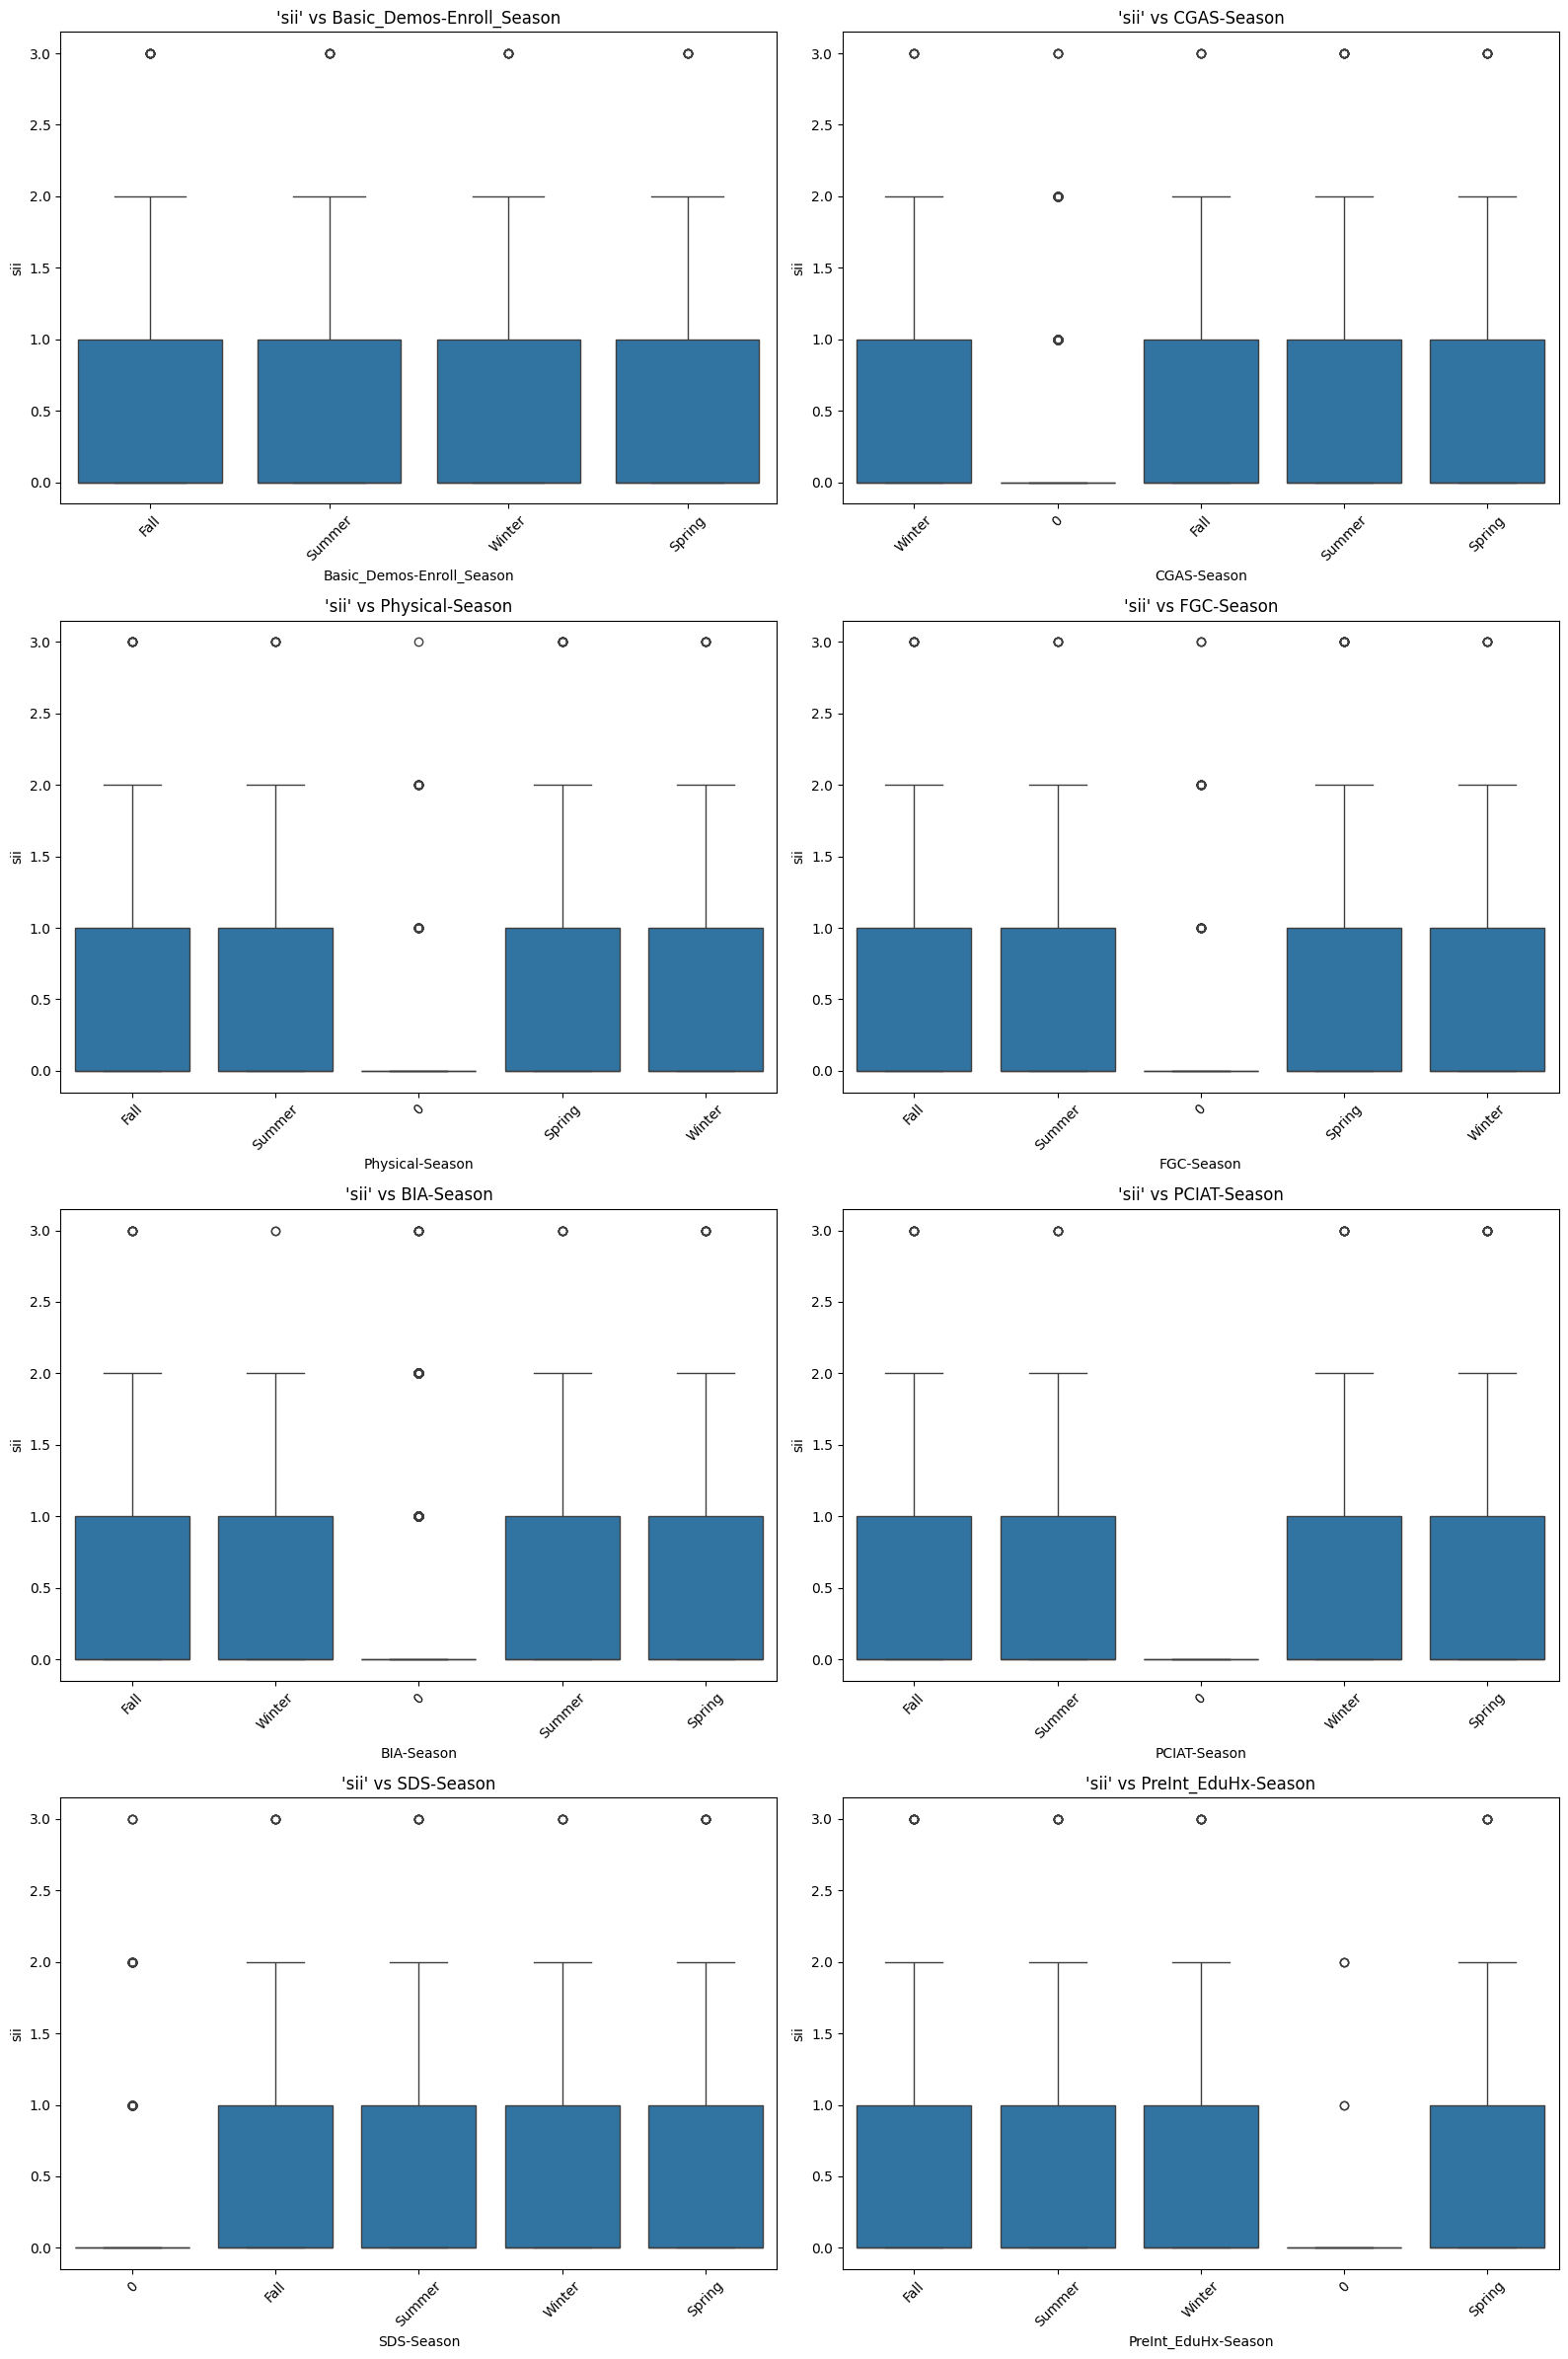

In [21]:
categorical_coulmns=["Basic_Demos-Enroll_Season","CGAS-Season","Physical-Season",
                     "FGC-Season","BIA-Season","PCIAT-Season","SDS-Season","PreInt_EduHx-Season"]
plt.figure(figsize=(16,24))
for i,col in enumerate (categorical_coulmns,1):
    plt.subplot(4,2,i)
    sns.boxplot(x=col, y="sii" , data=train_cleaned_df)
    plt.xticks(rotation=45)
    plt.title(f"'sii' vs {col}")
    
plt.tight_layout()
plt.show()
    


In [48]:
season_coulmns=[
    "Basic_Demos-Enroll_Season","CGAS-Season","Physical-Season",
                     "FGC-Season","BIA-Season","PCIAT-Season","PreInt_EduHx-Season",'SDS-Season']

season_mapping={
    "Spring" : 0 ,
    "Summer" : 1 ,
    "Fall" : 2 ,
    "Winter" : 3
}
for col in season_coulmns:
    if col in train_cleaned_df.columns:
        train_cleaned_df[col]=train_cleaned_df[col].replace(season_mapping)
    


C:\Users\DELL\AppData\Local\Temp\ipykernel_6508\3481150956.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_cleaned_df[col]=train_cleaned_df[col].replace(season_mapping)


In [49]:
train_cleaned_df.head(4)

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PCIAT-Season,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,2,5,0,3,51.0,2,16.877316,46.0,50.8,0.0,0.0,0.0,2,0.0,0.0,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,2,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,2,5.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,0,0.0,0.0,2,3.0,2.0
1,000fd460,1,9,0,0,0.0,2,14.035590,48.0,46.0,75.0,70.0,122.0,2,3.0,0.0,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,3,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.21172,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,46.0,64.0,1,0.0,0.0
2,00105258,1,10,1,2,71.0,2,16.648696,56.5,75.6,65.0,94.0,117.0,2,20.0,1.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,0,0.0,0.00000,0.0000,0.000,0.00,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.0000,0.00000,0.0000,0.0000,0.0000,2,5.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,2,38.0,54.0,1,2.0,0.0
3,00115b9f,3,9,0,2,71.0,1,18.292347,56.0,81.6,60.0,97.0,117.0,1,18.0,1.0,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,1,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.22033,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,1,4.0,2.0,4.0,0.0,5.0,1.0,0.0,3.0,2.0,2.0,3.0,0.0,3.0,0.0,0.0,3.0,4.0,3.0,4.0,1.0,44.0,1,31.0,45.0,3,0.0,1.0


In [50]:
train_data_no_id = train_cleaned_df.drop(columns=['id'], errors='ignore')

In [51]:
train_data_no_id .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 68 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Basic_Demos-Enroll_Season               3960 non-null   int64  
 1   Basic_Demos-Age                         3960 non-null   int64  
 2   Basic_Demos-Sex                         3960 non-null   int64  
 3   CGAS-Season                             3960 non-null   int64  
 4   CGAS-CGAS_Score                         3960 non-null   float64
 5   Physical-Season                         3960 non-null   int64  
 6   Physical-BMI                            3960 non-null   float64
 7   Physical-Height                         3960 non-null   float64
 8   Physical-Weight                         3960 non-null   float64
 9   Physical-Diastolic_BP                   3960 non-null   float64
 10  Physical-HeartRate                      3960 non-null   floa

In [52]:
print(train_data_no_id.dtypes)


Basic_Demos-Enroll_Season                   int64
Basic_Demos-Age                             int64
Basic_Demos-Sex                             int64
CGAS-Season                                 int64
CGAS-CGAS_Score                           float64
Physical-Season                             int64
Physical-BMI                              float64
Physical-Height                           float64
Physical-Weight                           float64
Physical-Diastolic_BP                     float64
Physical-HeartRate                        float64
Physical-Systolic_BP                      float64
FGC-Season                                  int64
FGC-FGC_CU                                float64
FGC-FGC_CU_Zone                           float64
FGC-FGC_PU                                float64
FGC-FGC_PU_Zone                           float64
FGC-FGC_SRL                               float64
FGC-FGC_SRL_Zone                          float64
FGC-FGC_SRR                               float64


In [53]:
non_numeric_cols = train_data_no_id.select_dtypes(exclude=['number']).columns
print("Non-numeric columns:", non_numeric_cols)

Non-numeric columns: Index([], dtype='object')


In [54]:
train_data_numeric = train_data_no_id.select_dtypes(include=['number'])
correlation_matrix = train_data_numeric.corr()

In [56]:
print(train_data_no_id.isnull().sum())


Basic_Demos-Enroll_Season                 0
Basic_Demos-Age                           0
Basic_Demos-Sex                           0
CGAS-Season                               0
CGAS-CGAS_Score                           0
Physical-Season                           0
Physical-BMI                              0
Physical-Height                           0
Physical-Weight                           0
Physical-Diastolic_BP                     0
Physical-HeartRate                        0
Physical-Systolic_BP                      0
FGC-Season                                0
FGC-FGC_CU                                0
FGC-FGC_CU_Zone                           0
FGC-FGC_PU                                0
FGC-FGC_PU_Zone                           0
FGC-FGC_SRL                               0
FGC-FGC_SRL_Zone                          0
FGC-FGC_SRR                               0
FGC-FGC_SRR_Zone                          0
FGC-FGC_TL                                0
FGC-FGC_TL_Zone                 

In [57]:
correlation_matrix = train_data_no_id.corr()


In [58]:
correlation_matrix = train_data_no_id.corr()

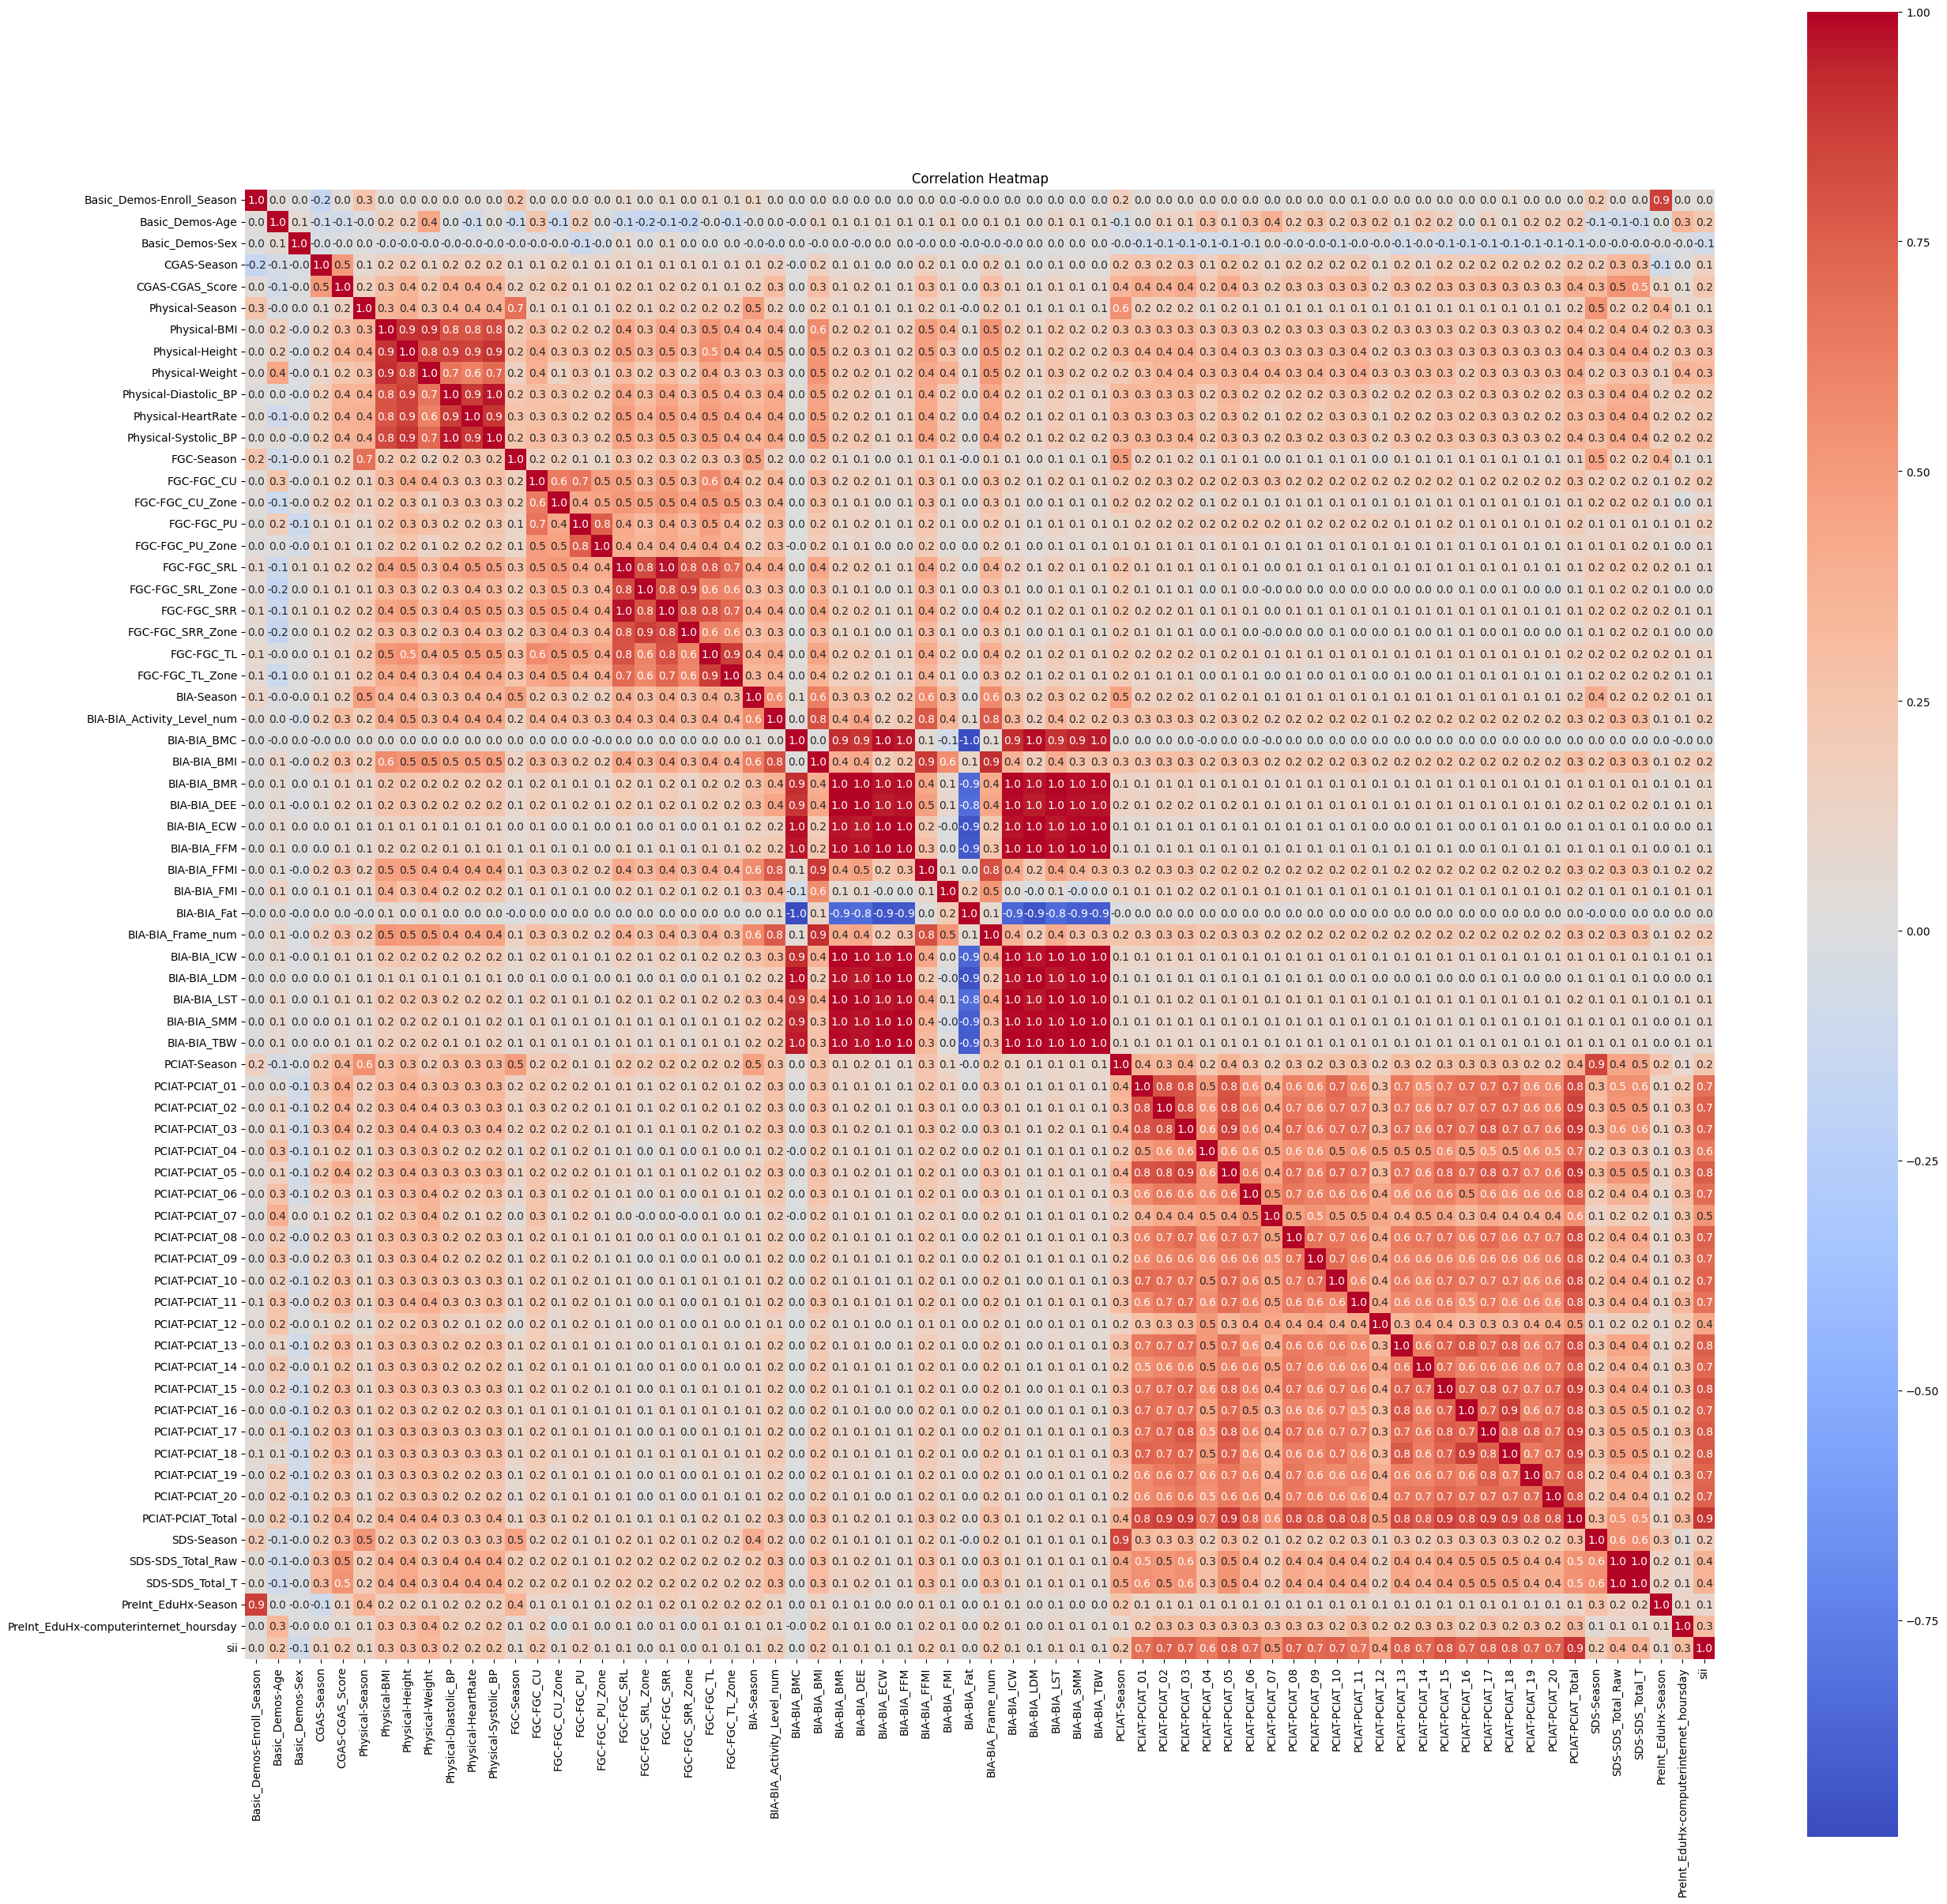

In [59]:
plt.figure(figsize=(30, 30))
sns.heatmap(correlation_matrix, annot=True, fmt='.1f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()


In [60]:
common_columns =train_cleaned_df.columns.intersection(test_df.columns)
# Prepare the feature matrix X and target vector y
X = train_cleaned_df[common_columns].drop(columns=['id'])
y = train_cleaned_df['sii']

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [62]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
pca = PCA(n_components=0.95)  
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [86]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)

xgb_search = RandomizedSearchCV(xgb, param_grid, n_iter=10, scoring='accuracy', cv=5, n_jobs=-1, random_state=42)
xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
print("Best XGBoost Parameters:", xgb_search.best_params_)

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:158: UserWarning: [20:17:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best XGBoost Parameters: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [89]:
from sklearn.feature_selection import SelectFromModel

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

selector = SelectFromModel(rf, threshold='median', prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [92]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
best_xgb = XGBClassifier(
    subsample=0.7,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    colsample_bytree=1.0,
    eval_metric="mlogloss",
    random_state=42
)
best_rf = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42)

stack_model = StackingClassifier(estimators=[
    ('rf', best_rf),
    ('xgb',best_xgb)
], final_estimator=LogisticRegression())

stack_model.fit(X_train_selected, y_train)
print("Stacking Accuracy:", stack_model.score(X_test_selected , y_test))

Stacking Accuracy: 0.7222222222222222
